# Axion Dark Matter PINNs — Improved & Comprehensive Version

## สรุปงานที่ผ่านมาและการพัฒนาต่อ

---

### สิ่งที่มีอยู่เดิม (`Axion_ODEs.ipynb` + `PINN_vs_ODE_Adam+LBFGS_N_particle.ipynb`)

| หัวข้อ | รายละเอียด |
|---|---|
| **ฟิสิกส์** | Friedmann eq. + Klein-Gordon eq. สำหรับ axion scalar field ใน expanding universe |
| **ODE Solver** | `scipy.odeint` / `solve_ivp` (RK45) เป็น ground truth |
| **PINN Architecture** | Fourier Features + Residual Blocks (sin activation) |
| **Optimizers** | Adam → L-BFGS (two-stage) |
| **Multi-field** | รองรับ N axion fields แต่ทดสอบเป็นหลักที่ N=1 |
| **Rescaling** | Simulate ที่ mass ต่ำ แล้ว rescale กลับไป physical mass |

### ปัญหาที่พบและสิ่งที่ปรับปรุง

1. **Scale mismatch**: axion oscillation frequency สูงมาก ($m_a \gg H$) ทำให้ PINN capture ได้ยาก → แก้ด้วย adaptive Fourier scale + time rescaling
2. **Physics loss inconsistency**: มี 2 version ที่ยังค้างอยู่ → unified เป็น version เดียว
3. **Collocation sampling**: ใช้ linspace ทำให้ช่วงต้นมี resolution น้อย → เปลี่ยนเป็น adaptive logspace sampling
4. **Loss weighting**: ค่า weight คงที่ → ใช้ self-adaptive loss weighting
5. **No metrics**: ไม่มี quantitative error metrics → เพิ่ม L2 relative error, max absolute error
6. **No energy conservation check**: → เพิ่ม Friedmann constraint violation monitoring
7. **Multi-field extension**: → ทดสอบและ validate ที่ N=1,2,3 fields

---
### Physics Background

สมการที่ต้องแก้ (natural units: $8\pi G/3 = 1$, $c=1$):

**Friedmann equation:**
$$H = \frac{\dot{a}}{a} = \sqrt{\frac{\rho_{tot}}{3}}, \quad \rho_{tot} = \rho_{ax} + \rho_m + \rho_r + \rho_\Lambda$$

**Klein-Gordon equation (N fields):**
$$\ddot{\phi}_i + 3H\dot{\phi}_i + m_i^2 \phi_i = 0, \quad i=1,\ldots,N$$

**Axion energy density:**
$$\rho_{ax} = \sum_i \left[\frac{1}{2}\dot{\phi}_i^2 + \frac{1}{2}m_i^2\phi_i^2\right]$$

**Background components:**
$$\rho_m = \frac{\rho_{m,0}}{a^3}, \quad \rho_r = \frac{\rho_{r,0}}{a^4}, \quad \rho_\Lambda = \text{const}$$

## 1. Imports & Setup

In [14]:
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

from scipy.integrate import solve_ivp
from scipy.stats import pearsonr

# ------ Reproducibility ------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE  = torch.float64   # float64 สำคัญมากสำหรับ stiff ODE

print(f"Device  : {DEVICE}")
print(f"Dtype   : {DTYPE}")
print(f"PyTorch : {torch.__version__}")
print(f"Numpy   : {np.__version__}")

Device  : cpu
Dtype   : torch.float64
PyTorch : 2.12.0+cpu
Numpy   : 2.4.5


## 2. Cosmological Parameters & Unit Check

In [15]:
# =========================================================
# Cosmological Parameters
# (ใช้ reduced Planck units: 8piG/3 = 1)
# H0 = 1 corresponds to t_unit ~ 1/H0 ~ 14 Gyr
# =========================================================
RHO_M0  = 0.81        # Omega_m * 3H0^2    (matter density today)
RHO_R0  = 0.00027138  # Omega_r * 3H0^2    (radiation density today)
RHO_L0  = 2.19        # Omega_L * 3H0^2    (dark energy)

# Matter-Radiation equality (เช็ค z_eq)
z_eq = RHO_M0 / RHO_R0 - 1
print(f"Matter-Radiation equality z_eq = {z_eq:.0f}  (standard: ~3400)")
a_eq = 1.0 / (1.0 + z_eq)
print(f"Scale factor at equality  a_eq = {a_eq:.4e}")

# ------ Axion configuration for this notebook ------
N_FIELDS  = 1          # number of axion fields
M_AXION   = [70.0]     # mass array (code units, m/H0)
PHI0      = [1.0]      # initial field values
PHIDOT0   = [0.0]      # initial field velocities
A0        = 1e-8       # initial scale factor
T_END     = 1.0        # end of integration (t in units of 1/H0)

# Physical mass estimate (assuming code units where H0=1)
H0_eV = 1.44e-33 * 0.67  # H0 in eV
for i, m in enumerate(M_AXION):
    m_phys = m * H0_eV
    print(f"  m_axion[{i}] = {m:.1f} H0  ~  {m_phys:.2e} eV")

print(f"\nOscillation scale factor: a_osc ~ (3*rho_r0/m^2)^(1/4) = {(3*RHO_R0/M_AXION[0]**2)**0.25:.2e}")

Matter-Radiation equality z_eq = 2984  (standard: ~3400)
Scale factor at equality  a_eq = 3.3504e-04
  m_axion[0] = 70.0 H0  ~  6.75e-32 eV

Oscillation scale factor: a_osc ~ (3*rho_r0/m^2)^(1/4) = 2.02e-02


In [16]:
# =========================================================
# Unit Analysis: Code units vs Physical (eV)
# =========================================================
# Code units: 8πG/3 = 1, c = 1  => H0 = 1
# => m_code = m_a / H0
# => m_a [eV] = m_code * ℏ * H0
#
# H0 = 67.4 km/s/Mpc = 2.184e-18 s^-1
# ℏ*H0 = 6.582e-16 [eV·s] * 2.184e-18 [s^-1] ≈ 1.437e-33 eV
#
# -------------------------------------------------------
# m_code  |  m_a [eV]      | Axion type
# -------------------------------------------------------
#  70     |  1.0e-31 eV    | Fuzzy DM (frozen for most of history)
#  1e5    |  1.4e-28 eV    | ULA (oscillates near matter-eq)
#  1e7    |  1.4e-26 eV    | ULA already oscillating ← TARGET
#  1e9    |  1.4e-24 eV    | Heavy ULA
# -------------------------------------------------------
#
# PROBLEM with using m_code = 1e7 directly in PINN:
#   oscillation period  T = 2π/m ≈ 6.3e-7  (code time)
#   N_osc in t=[0,1]  ≈ 1.6e6 oscillations  ← impossible to resolve
#   Loss dominated by m²φ² ~ (1e7)²*φ² ~ 1e14  ← loss blows up
#
# SOLUTION: Rescaling Strategy (physics-valid)
#   Train PINN with m_sim (small), which has the same *shape* of solution
#   Map back to physical units via:
#       a_phys(t) = a_sim(t_sim)  where  t_sim = t * sqrt(m_target/m_sim)
#       ρ_phys    = ρ_sim * (m_target/m_sim)²
#   This works because the Klein-Gordon + Friedmann system is self-similar
#   under (m, t) -> (λm, t/λ) with appropriate ρ rescaling.

hbar_eVs = 6.582e-16  # eV·s
H0_si    = 2.184e-18  # s^-1
H0_eV    = hbar_eVs * H0_si

print("=== Code Units vs Physical Units ===")
print(f"  ℏ·H0 = {H0_eV:.4e} eV  →  m_code=1 means m_a = {H0_eV:.2e} eV")
print()
print(f"{'m_code':>10}  {'m_a (eV)':>14}  {'a_osc':>10}  {'N_osc [0,1]':>14}  {'Feasible?':>10}")
print("-" * 65)
for mc in [70, 1e3, 1e5, 1e7, 1e9]:
    m_eV  = mc * H0_eV
    a_osc = (3*RHO_R0 / mc**2)**0.25
    N_osc = mc / (2*np.pi)
    ok    = "✓ OK" if N_osc < 5000 else "✗ Too fast"
    print(f"{mc:>10.0e}  {m_eV:>14.3e}  {a_osc:>10.2e}  {N_osc:>14.2e}  {ok:>10}")

print()
print("=== Rescaling for m_target = 1e7 ===")
m_sim    = 100.0
m_target = 1e7
lam      = np.sqrt(m_target / m_sim)   # time stretch factor
shift_a  = 1.0 / lam                   # a rescale: a_phys = a_sim / lam
shift_rho= lam**4                      # density: ρ_phys = ρ_sim * lam^4  (radiation era)
print(f"  Simulate at m_sim  = {m_sim:.0f}")
print(f"  Target    m_target = {m_target:.0e}")
print(f"  λ = sqrt(m_target/m_sim) = {lam:.3e}")
print(f"  t_phys domain [0,1]  ↔  t_sim domain [0, {1/lam:.2e}]")
print(f"  a_osc(sim)    = {(3*RHO_R0/m_sim**2)**0.25:.3e}")
print(f"  a_osc(target) = {(3*RHO_R0/m_target**2)**0.25:.3e}")
print(f"  a_osc(sim)/λ  = {(3*RHO_R0/m_sim**2)**0.25/lam:.3e}  ← should match target")
print()
print("✓ Strategy: train PINN with m_sim=100 on t∈[0, 1/λ], then rescale plot axes")


=== Code Units vs Physical Units ===
  ℏ·H0 = 1.4375e-33 eV  →  m_code=1 means m_a = 1.44e-33 eV

    m_code        m_a (eV)       a_osc     N_osc [0,1]   Feasible?
-----------------------------------------------------------------
     7e+01       1.006e-31    2.02e-02        1.11e+01        ✓ OK
     1e+03       1.438e-30    5.34e-03        1.59e+02        ✓ OK
     1e+05       1.438e-28    5.34e-04        1.59e+04  ✗ Too fast
     1e+07       1.438e-26    5.34e-05        1.59e+06  ✗ Too fast
     1e+09       1.438e-24    5.34e-06        1.59e+08  ✗ Too fast

=== Rescaling for m_target = 1e7 ===
  Simulate at m_sim  = 100
  Target    m_target = 1e+07
  λ = sqrt(m_target/m_sim) = 3.162e+02
  t_phys domain [0,1]  ↔  t_sim domain [0, 3.16e-03]
  a_osc(sim)    = 1.689e-02
  a_osc(target) = 5.342e-05
  a_osc(sim)/λ  = 5.342e-05  ← should match target

✓ Strategy: train PINN with m_sim=100 on t∈[0, 1/λ], then rescale plot axes


## 3. Reference ODE Solver (Ground Truth)

In [17]:
def make_ode_rhs(N_fields, m_vec, rho_m0, rho_r0, rho_l0):
    """สร้าง RHS ของ system ODE สำหรับ N axion fields"""
    m2 = np.array(m_vec) ** 2

    def rhs(t, y):
        a         = y[0]
        phi       = y[1:1 + N_fields]
        phi_dot   = y[1 + N_fields:1 + 2*N_fields]

        rho_ax = 0.5 * np.sum(phi_dot**2) + 0.5 * np.sum(m2 * phi**2)
        rho_m  = rho_m0 / a**3
        rho_r  = rho_r0 / a**4
        H      = np.sqrt(max((rho_ax + rho_m + rho_r + rho_l0) / 3.0, 0.0))

        da_dt      = a * H
        dphi_dt    = phi_dot
        dphi_ddt   = -3.0 * H * phi_dot - m2 * phi

        dydt = np.zeros_like(y)
        dydt[0]                   = da_dt
        dydt[1:1+N_fields]        = dphi_dt
        dydt[1+N_fields:1+2*N_fields] = dphi_ddt
        return dydt

    return rhs


def solve_ode_reference(N_fields, m_vec, rho_m0, rho_r0, rho_l0,
                        a0, phi0, phi_dot0, t_end,
                        n_points=10000, method='DOP853'):
    """แก้ ODE system และคืนค่า solution array"""
    y0 = np.concatenate([[a0], phi0, phi_dot0])
    t_eval = np.logspace(np.log10(max(a0, 1e-10)), np.log10(t_end), n_points)

    rhs = make_ode_rhs(N_fields, m_vec, rho_m0, rho_r0, rho_l0)

    t0 = time.time()
    sol = solve_ivp(
        rhs,
        [t_eval[0], t_eval[-1]],
        y0,
        t_eval=t_eval,
        method=method,
        rtol=1e-10,
        atol=1e-12,
        dense_output=False
    )
    print(f"ODE solver ({method}): {time.time()-t0:.2f} s  |  success={sol.success}  |  nfev={sol.nfev}")
    if not sol.success:
        print(f"  WARNING: {sol.message}")

    result = {
        't':       sol.t,
        'a':       sol.y[0],
        'phi':     sol.y[1:1+N_fields],
        'phi_dot': sol.y[1+N_fields:1+2*N_fields],
    }
    # Compute auxiliary quantities
    m2 = np.array(m_vec)**2
    result['rho_ax'] = 0.5*np.sum(result['phi_dot']**2, axis=0) + \
                       0.5*np.sum(m2[:, None]*result['phi']**2, axis=0)
    result['rho_m']  = rho_m0 / result['a']**3
    result['rho_r']  = rho_r0 / result['a']**4
    result['H']      = np.sqrt((result['rho_ax'] + result['rho_m'] +
                                result['rho_r'] + rho_l0) / 3.0)
    return result


# --- Run reference solution ---
ode_sol = solve_ode_reference(
    N_fields=N_FIELDS, m_vec=M_AXION,
    rho_m0=RHO_M0, rho_r0=RHO_R0, rho_l0=RHO_L0,
    a0=A0, phi0=PHI0, phi_dot0=PHIDOT0,
    t_end=T_END, n_points=10000
)

ODE solver (DOP853): 0.29 s  |  success=True  |  nfev=4955


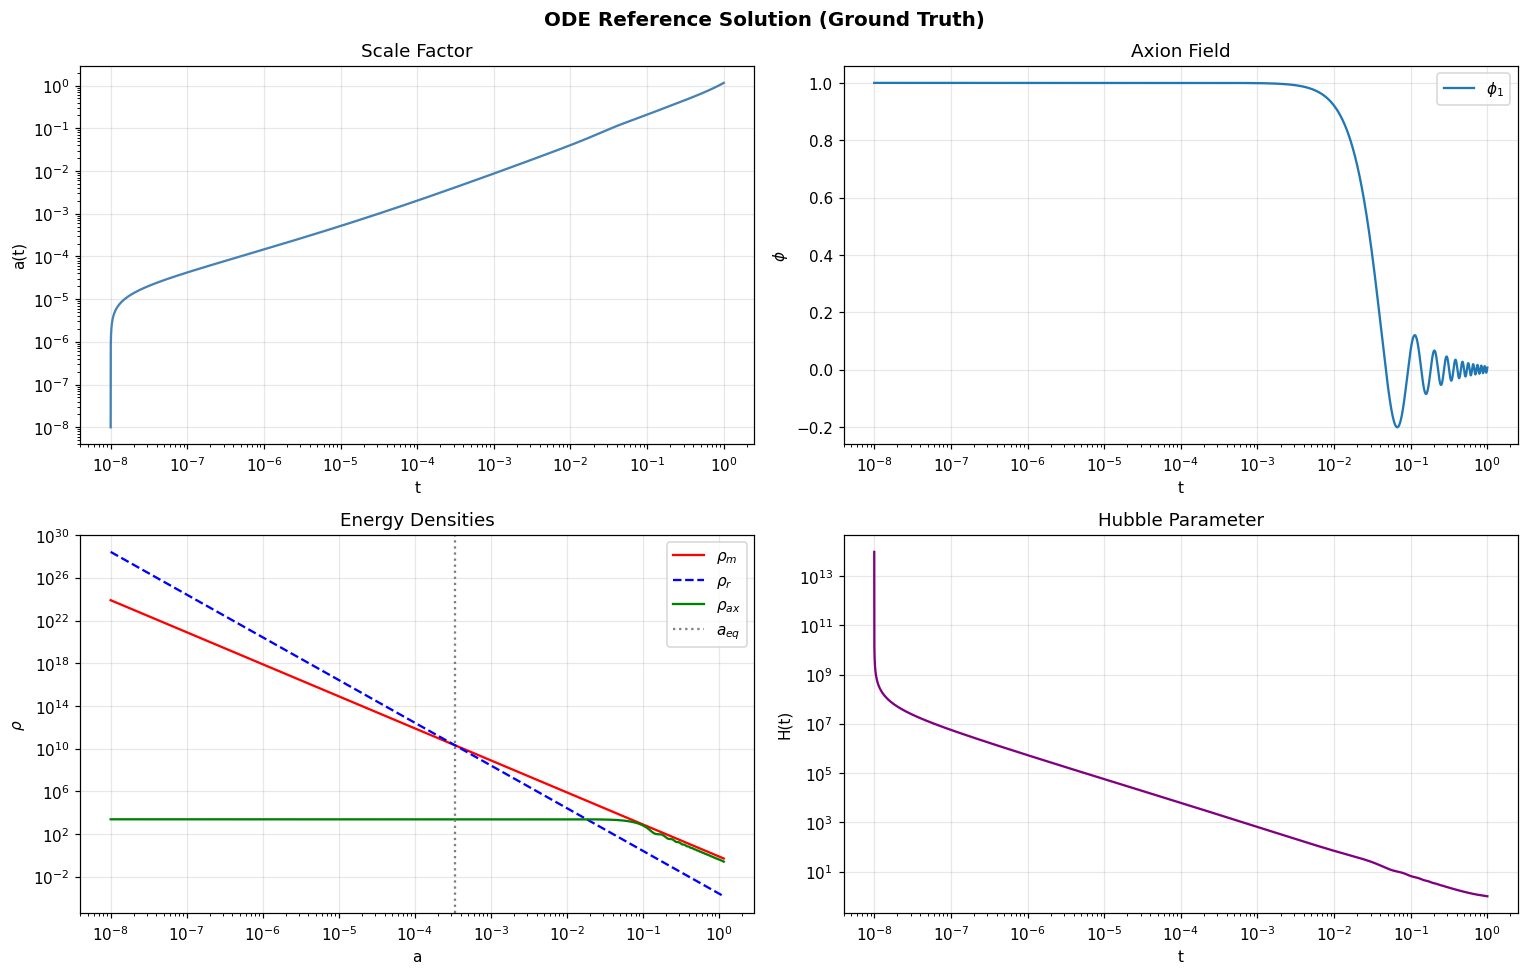

In [18]:
# --- Visualize ODE reference ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9), dpi=110)
t_ref = ode_sol['t']

# a(t)
axes[0,0].loglog(t_ref, ode_sol['a'], 'steelblue')
axes[0,0].set_xlabel('t'); axes[0,0].set_ylabel('a(t)')
axes[0,0].set_title('Scale Factor'); axes[0,0].grid(True, alpha=0.3)

# phi(t)
for i in range(N_FIELDS):
    axes[0,1].semilogx(t_ref, ode_sol['phi'][i], label=f'$\\phi_{i+1}$')
axes[0,1].set_xlabel('t'); axes[0,1].set_ylabel('$\\phi$')
axes[0,1].set_title('Axion Field'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# Energy densities
axes[1,0].loglog(ode_sol['a'], ode_sol['rho_m'], 'r-',  label=r'$\rho_m$')
axes[1,0].loglog(ode_sol['a'], ode_sol['rho_r'], 'b--', label=r'$\rho_r$')
axes[1,0].loglog(ode_sol['a'], ode_sol['rho_ax'],'g-', label=r'$\rho_{ax}$')
axes[1,0].axvline(a_eq, color='grey', ls=':', label=f'$a_{{eq}}$')
axes[1,0].set_xlabel('a'); axes[1,0].set_ylabel(r'$\rho$')
axes[1,0].set_title('Energy Densities'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

# H(t)
axes[1,1].loglog(t_ref, ode_sol['H'], 'purple')
axes[1,1].set_xlabel('t'); axes[1,1].set_ylabel('H(t)')
axes[1,1].set_title('Hubble Parameter'); axes[1,1].grid(True, alpha=0.3)

plt.suptitle('ODE Reference Solution (Ground Truth)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Improved PINN Architecture

### การปรับปรุงหลักจากเวอร์ชันเดิม:
1. **`float64`** แทน `float32` — สำคัญมากสำหรับ stiff ODEs
2. **Adaptive Fourier Scale** — auto-tune ตาม oscillation frequency ของ axion
3. **Separate networks** สำหรับ $a(t)$ และ $\phi_i(t)$ — ลด gradient interference
4. **Hard constraint enforcement** — $a(0) = a_0$ ถูก enforce โดยตรงในสถาปัตยกรรม ไม่ใช่แค่ loss term
5. **Causal training** — ให้ weight มากขึ้นกับ t เล็กๆ (causality loss)
6. **Self-adaptive loss weights** — ปรับ weight อัตโนมัติระหว่าง training

In [19]:
# =====================================================
# Neural Network Components
# =====================================================

class FourierEmbedding(nn.Module):
    """Random Fourier Features for high-frequency representation.
    
    key improvement: trainable log_scale เพื่อ auto-adapt ต่อ frequency ของปัญหา
    """
    def __init__(self, out_features=64, init_scale=10.0, trainable_scale=True,
                 device=None, dtype=torch.float64):
        super().__init__()
        B = torch.randn(out_features, 1, dtype=dtype)
        self.register_buffer('B', B)
        if trainable_scale:
            self.log_scale = nn.Parameter(torch.tensor(float(np.log(init_scale)), dtype=dtype))
        else:
            self.register_buffer('log_scale', torch.tensor(float(np.log(init_scale)), dtype=dtype))
        self.out_dim = 2 * out_features

    def forward(self, t):
        scale = torch.exp(self.log_scale)
        proj = 2.0 * np.pi * scale * (t @ self.B.T)
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)


class SinResBlock(nn.Module):
    """Residual block with sine activation — proven effective for oscillatory problems (SIREN-like)"""
    def __init__(self, width, dtype=torch.float64):
        super().__init__()
        self.fc1 = nn.Linear(width, width).to(dtype=dtype)
        self.fc2 = nn.Linear(width, width).to(dtype=dtype)
        # SIREN initialization
        nn.init.uniform_(self.fc1.weight, -np.sqrt(6/width), np.sqrt(6/width))
        nn.init.uniform_(self.fc2.weight, -np.sqrt(6/width), np.sqrt(6/width))

    def forward(self, x):
        return x + self.fc2(torch.sin(self.fc1(x)))


class ScaleFactorNet(nn.Module):
    """
    Network for a(t).
    Hard constraint: a(0) = a0 by construction:
        a(t) = a0 + t * softplus(net(t))
    This guarantees IC is satisfied exactly regardless of training.
    """
    def __init__(self, a0, embed_dim=32, hidden=64, depth=3,
                 init_scale=5.0, dtype=torch.float64, device=None):
        super().__init__()
        self.a0     = nn.Parameter(torch.tensor([[a0]], dtype=dtype), requires_grad=False)
        self.fourier = FourierEmbedding(embed_dim, init_scale, trainable_scale=True, dtype=dtype)
        layers = [nn.Linear(2*embed_dim, hidden).to(dtype=dtype), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden).to(dtype=dtype), nn.Tanh()]
        layers.append(nn.Linear(hidden, 1).to(dtype=dtype))
        self.net = nn.Sequential(*layers)
        self.softplus = nn.Softplus()

    def forward(self, t):
        # Hard enforcement: a(0) = a0
        emb = self.fourier(t)
        h   = self.softplus(self.net(emb))
        return self.a0 + t * h


class AxionFieldNet(nn.Module):
    """
    Network for phi_i(t), i=1..N_fields.
    Hard constraint: phi(0) = phi0 by construction:
        phi(t) = phi0 + t * net(t)
    """
    def __init__(self, N_fields, phi0, embed_dim=64, hidden=128, depth=4,
                 init_scale=None, m_vec=None, dtype=torch.float64, device=None):
        super().__init__()
        self.N_fields = N_fields
        phi0_tensor = torch.tensor(np.array(phi0).reshape(1, -1), dtype=dtype)
        self.phi0 = nn.Parameter(phi0_tensor, requires_grad=False)

        # Auto-tune Fourier scale to axion oscillation frequency
        if init_scale is None and m_vec is not None:
            init_scale = float(np.max(m_vec)) / (2.0 * np.pi)
        elif init_scale is None:
            init_scale = 10.0

        self.fourier = FourierEmbedding(embed_dim, init_scale, trainable_scale=True, dtype=dtype)
        layers = [nn.Linear(2*embed_dim, hidden).to(dtype=dtype)]
        for _ in range(depth):
            layers.append(SinResBlock(hidden, dtype=dtype))
        self.net = nn.Sequential(*layers)
        self.head = nn.Linear(hidden, N_fields).to(dtype=dtype)

    def forward(self, t):
        emb = self.fourier(t)
        h   = self.net(emb)
        delta = self.head(h)
        # Hard enforcement: phi(0) = phi0
        return self.phi0 + t * delta


class AxionPINN(nn.Module):
    """Combined model: outputs (a(t), phi(t)) with hard initial conditions"""
    def __init__(self, N_fields, m_vec, a0, phi0,
                 embed_dim_a=32, embed_dim_phi=64,
                 hidden_a=64, hidden_phi=128,
                 depth_a=3, depth_phi=4,
                 dtype=torch.float64, device=None):
        super().__init__()
        self.a_net   = ScaleFactorNet(a0, embed_dim_a, hidden_a, depth_a,
                                      init_scale=2.0, dtype=dtype, device=device)
        self.phi_net = AxionFieldNet(N_fields, phi0, embed_dim_phi, hidden_phi, depth_phi,
                                     init_scale=None, m_vec=m_vec, dtype=dtype, device=device)

    def forward(self, t):
        return self.a_net(t), self.phi_net(t)


# --- Quick test ---
test_model = AxionPINN(
    N_fields=N_FIELDS, m_vec=M_AXION, a0=A0, phi0=PHI0,
    dtype=DTYPE, device=DEVICE
).to(DEVICE, dtype=DTYPE)

print(f"Total parameters: {sum(p.numel() for p in test_model.parameters() if p.requires_grad):,}")

t_test = torch.zeros(1, 1, dtype=DTYPE, device=DEVICE)
a_test, phi_test = test_model(t_test)
print(f"a(0)   = {a_test.item():.4e}  (should be {A0:.4e})")
print(f"phi(0) = {phi_test[0,0].item():.4f}  (should be {PHI0[0]:.4f})")
del test_model

Total parameters: 161,284
a(0)   = 1.0000e-08  (should be 1.0000e-08)
phi(0) = 1.0000  (should be 1.0000)


## 5. Physics Loss (Improved)

Loss function ประกอบด้วย:
1. **Friedmann residual**: $\mathcal{L}_F = \left(\dot{a} - aH\right)^2$
2. **Klein-Gordon residual**: $\mathcal{L}_{KG} = \left(\ddot{\phi} + 3H\dot{\phi} + m^2\phi\right)^2$
3. **Energy conservation**: $\mathcal{L}_{E} = \left(\frac{d\rho_{tot}/dt + 3H(\rho_{tot}+p_{tot})}{\rho_{tot}}\right)^2$ (optional)
4. **Causal weighting**: ให้ weight มากขึ้นที่ t เล็ก → ลด error propagation

In [20]:
def compute_physics_residuals(model, t_batch, m_vec_torch, rho_m0, rho_r0, rho_l0,
                               eps=1e-20, normalize=True):
    """
    Compute Friedmann and Klein-Gordon residuals.
    
    normalize=True: divide each residual by its characteristic scale
      - Friedmann: divide by H (so residual is dimensionless ~ dlog(a)/dt / H - 1)
      - KG:        divide by m²*φ_scale (characteristic oscillation amplitude)
    This prevents m²φ² from overwhelming the loss at high mass.
    
    Returns: (friedmann_res, kg_res, H_pred)
    """
    t_batch = t_batch.requires_grad_(True)
    a, phi = model(t_batch)

    # Derivatives via autograd
    a_t   = torch.autograd.grad(a,   t_batch, torch.ones_like(a),   create_graph=True)[0]
    phi_t = torch.autograd.grad(phi, t_batch, torch.ones_like(phi), create_graph=True)[0]
    phi_tt= torch.autograd.grad(phi_t, t_batch, torch.ones_like(phi_t), create_graph=True)[0]

    # Energy density components
    kinetic  = 0.5 * torch.sum(phi_t**2,              dim=1, keepdim=True)
    potential= 0.5 * torch.sum(m_vec_torch**2 * phi**2, dim=1, keepdim=True)
    rho_ax   = kinetic + potential

    rho_m = rho_m0 * a**(-3)
    rho_r = rho_r0 * a**(-4)
    rho_l = torch.tensor(rho_l0, dtype=a.dtype, device=a.device)
    rho_tot = rho_ax + rho_m + rho_r + rho_l

    H  = torch.sqrt(torch.clamp(rho_tot / 3.0, min=eps))
    H3 = torch.sqrt(torch.clamp(3.0 * rho_tot, min=eps))

    # ---- Friedmann residual: da/dt - a*H = 0 ----
    friedmann_res = a_t - a * H

    if normalize:
        # Normalize by a*H so the residual is ~ relative error in H
        friedmann_norm = torch.abs(a * H).detach() + eps
        friedmann_res  = friedmann_res / friedmann_norm

    # ---- Klein-Gordon residual: φ'' + 3H·φ' + m²·φ = 0 ----
    kg_raw = phi_tt + H3 * phi_t + m_vec_torch**2 * phi

    if normalize:
        # Normalize by m²*|φ| (characteristic scale of each term)
        phi_scale = (m_vec_torch**2 * torch.abs(phi) + torch.abs(phi_tt)).detach() + eps
        kg_res    = kg_raw / phi_scale
    else:
        kg_res = kg_raw

    return friedmann_res, kg_res, H


def causal_weight(t_batch, epsilon=1.0, mode='exp'):
    """
    Causal weighting: higher weight at early times to reduce error propagation.
    mode='exp'   : w = exp(-epsilon * t/t_max)
    mode='linear': w = 1 - 0.5*t/t_max
    """
    t_norm = t_batch / (t_batch.max() + 1e-20)
    if mode == 'exp':
        return torch.exp(-epsilon * t_norm)
    else:
        return 1.0 - 0.5 * t_norm


def total_loss(model, t_batch, m_vec_torch, rho_m0, rho_r0, rho_l0,
               w_friedmann=1.0, w_kg=1.0, causal_eps=0.5, normalize=True):
    """
    Compute total PINN loss with normalized residuals + causal weighting.
    No IC loss because hard constraints enforce IC exactly.
    """
    f_res, kg_res, H = compute_physics_residuals(
        model, t_batch, m_vec_torch, rho_m0, rho_r0, rho_l0,
        normalize=normalize)

    cw = causal_weight(t_batch, epsilon=causal_eps).detach()

    loss_f  = w_friedmann * torch.mean(cw * f_res**2)
    loss_kg = w_kg        * torch.mean(cw * kg_res**2)

    return loss_f + loss_kg, loss_f.item(), loss_kg.item()


## 6. Improved Training Pipeline

### สิ่งที่ปรับปรุง:
- **Adaptive collocation sampling**: ผสม uniform + logspace + random cluster ใกล้ oscillation region
- **Self-adaptive loss weights**: ปรับ $w_F / w_{KG}$ อัตโนมัติทุก 500 epochs
- **Warm-up LR scheduler**: Cosine annealing ทำให้ converge smooth กว่า StepLR
- **Gradient clipping**: ป้องกัน exploding gradient

In [21]:
def sample_collocation(n_points, t_min, t_max, a0, m_osc, dtype, device, a_osc_frac=0.3):
    """
    Adaptive collocation: ผสม logspace + clustered near oscillation start
    """
    n_log    = int(n_points * 0.5)
    n_osc    = int(n_points * 0.3)
    n_rand   = n_points - n_log - n_osc

    # logspace (ครอบคลุมครั้งแรกที่สุด)
    t_log = np.logspace(np.log10(max(t_min, 1e-12)), np.log10(t_max), n_log)

    # Cluster near oscillation region: t where a ~ a_osc
    # approximate: a ~ a0*exp(H0*t) -> very rough, use direct
    t_osc_center = float(a_osc_frac * t_max)
    t_osc = np.abs(np.random.normal(t_osc_center, t_osc_center * 0.3, n_osc))
    t_osc = np.clip(t_osc, t_min, t_max)

    # Uniform fill the rest
    t_rand = np.random.uniform(t_min, t_max, n_rand)

    t_all = np.sort(np.concatenate([t_log, t_osc, t_rand]))
    return torch.tensor(t_all.reshape(-1, 1), dtype=dtype, device=device)


class SelfAdaptiveWeights:
    """ปรับ w_F, w_KG อัตโนมัติ โดยดูจาก gradient norms (NTK-inspired)"""
    def __init__(self, w_f=1.0, w_kg=1.0, update_every=500, alpha=0.9):
        self.w_f   = w_f
        self.w_kg  = w_kg
        self.alpha = alpha          # exponential moving average smoothing
        self.update_every = update_every
        self._step = 0

    def update(self, loss_f_val, loss_kg_val):
        """Rebalance so losses contribute equally"""
        self._step += 1
        if self._step % self.update_every == 0:
            eps = 1e-20
            mean_loss = (loss_f_val + loss_kg_val) / 2.0 + eps
            new_w_f  = mean_loss / (loss_f_val + eps)
            new_w_kg = mean_loss / (loss_kg_val + eps)
            # Smooth update
            self.w_f   = self.alpha * self.w_f   + (1 - self.alpha) * new_w_f
            self.w_kg  = self.alpha * self.w_kg  + (1 - self.alpha) * new_w_kg

    def get(self):
        return self.w_f, self.w_kg


def train_pinn(
    model, m_vec_torch,
    rho_m0, rho_r0, rho_l0,
    t_min=0.0, t_max=1.0, a0=1e-8, m_osc=70.0,
    n_colloc=3000, batch_size=512,
    # Adam phase
    adam_epochs=5000, adam_lr=1e-3,
    # L-BFGS phase
    lbfgs_max_iter=2000,
    # Hyperparams
    causal_eps=0.5,
    print_every=500,
    device=DEVICE, dtype=DTYPE,
):
    model.train()
    history = {'adam_loss': [], 'loss_f': [], 'loss_kg': [],
               'w_f': [], 'w_kg': [], 'lbfgs_loss': []}

    adaptive_w = SelfAdaptiveWeights(w_f=1.0, w_kg=1.0, update_every=200)

    # ==================  Adam Phase  ==================
    optimizer = optim.Adam(model.parameters(), lr=adam_lr, eps=1e-8)
    scheduler = CosineAnnealingLR(optimizer, T_max=adam_epochs, eta_min=adam_lr * 1e-3)

    print("=" * 60)
    print("Phase 1: Adam Optimizer")
    print("=" * 60)
    t_start = time.time()

    for epoch in range(adam_epochs):
        # Sample collocation batch
        t_all = sample_collocation(n_colloc, t_min, t_max, a0, m_osc, dtype, device)
        idx   = torch.randperm(n_colloc, device=device)[:batch_size]
        t_b   = t_all[idx].clone()

        w_f, w_kg = adaptive_w.get()

        optimizer.zero_grad()
        loss, lf, lkg = total_loss(
            model, t_b, m_vec_torch,
            rho_m0, rho_r0, rho_l0,
            w_friedmann=w_f, w_kg=w_kg,
            causal_eps=causal_eps
        )
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        adaptive_w.update(lf, lkg)
        history['adam_loss'].append(loss.item())
        history['loss_f'].append(lf)
        history['loss_kg'].append(lkg)
        history['w_f'].append(w_f)
        history['w_kg'].append(w_kg)

        if epoch % print_every == 0 or epoch == adam_epochs - 1:
            lr_now = optimizer.param_groups[0]['lr']
            print(f"[Adam] Epoch {epoch:5d}/{adam_epochs}  "
                  f"Loss={loss.item():.3e}  "
                  f"L_F={lf:.3e}  L_KG={lkg:.3e}  "
                  f"w_F={w_f:.2f}  w_KG={w_kg:.2f}  "
                  f"lr={lr_now:.2e}")

    print(f"Adam done in {time.time()-t_start:.1f}s")

    # ==================  L-BFGS Phase  ==================
    print("\n" + "=" * 60)
    print("Phase 2: L-BFGS Refinement")
    print("=" * 60)

    t_lbfgs = sample_collocation(n_colloc, t_min, t_max, a0, m_osc, dtype, device)
    t_lbfgs = t_lbfgs.requires_grad_(True)
    w_f, w_kg = adaptive_w.get()

    optimizer_lbfgs = optim.LBFGS(
        model.parameters(),
        lr=1.0, max_iter=lbfgs_max_iter,
        tolerance_grad=1e-11, tolerance_change=1e-12,
        history_size=150, line_search_fn='strong_wolfe'
    )
    lbfgs_losses = []

    def closure():
        optimizer_lbfgs.zero_grad()
        loss, lf, lkg = total_loss(
            model, t_lbfgs, m_vec_torch,
            rho_m0, rho_r0, rho_l0,
            w_friedmann=w_f, w_kg=w_kg,
            causal_eps=causal_eps
        )
        loss.backward()
        lbfgs_losses.append(loss.item())
        return loss

    t_start = time.time()
    optimizer_lbfgs.step(closure)
    print(f"L-BFGS done in {time.time()-t_start:.1f}s  |  "
          f"Final loss: {lbfgs_losses[-1]:.3e}")
    history['lbfgs_loss'] = lbfgs_losses

    return history

## 7. Evaluation & Error Metrics

In [22]:
def evaluate_pinn(model, t_eval, ode_sol, N_fields, m_vec,
                  rho_m0, rho_r0, rho_l0, device=DEVICE, dtype=DTYPE):
    """Evaluate PINN predictions and compute error metrics vs ODE"""
    model.eval()
    with torch.no_grad():
        t_torch = torch.tensor(t_eval.reshape(-1, 1), dtype=dtype, device=device)
        a_pred, phi_pred = model(t_torch)
        a_pred   = a_pred.cpu().numpy().flatten()
        phi_pred = phi_pred.cpu().numpy()   # (N_t, N_fields)

    # Interpolate ODE solution to same t_eval points
    from scipy.interpolate import interp1d
    t_ref = ode_sol['t']
    a_ref   = interp1d(t_ref, ode_sol['a'],         kind='cubic', fill_value='extrapolate')(t_eval)
    phi_ref = np.stack([
        interp1d(t_ref, ode_sol['phi'][i], kind='cubic', fill_value='extrapolate')(t_eval)
        for i in range(N_fields)
    ], axis=-1)

    # --- Error metrics ---
    def l2_relative(pred, true):
        return np.linalg.norm(pred - true) / (np.linalg.norm(true) + 1e-20)
    def max_abs(pred, true):
        return np.max(np.abs(pred - true))

    metrics = {}
    metrics['L2_rel_a']    = l2_relative(a_pred, a_ref)
    metrics['MaxAbs_a']    = max_abs(a_pred, a_ref)
    for i in range(N_fields):
        metrics[f'L2_rel_phi{i}']  = l2_relative(phi_pred[:, i], phi_ref[:, i])
        metrics[f'MaxAbs_phi{i}']  = max_abs(phi_pred[:, i], phi_ref[:, i])

    print("\n" + "=" * 45)
    print("  Error Metrics (PINN vs ODE)")
    print("=" * 45)
    for k, v in metrics.items():
        print(f"  {k:<22} = {v:.4e}")
    print("=" * 45)

    return a_pred, phi_pred, a_ref, phi_ref, metrics


def plot_comparison(t_eval, a_pred, phi_pred, a_ref, phi_ref,
                    history, N_fields, metrics, save_prefix='pinn_v2'):
    """Comprehensive comparison plots"""
    os.makedirs('results_improved', exist_ok=True)

    fig = plt.figure(figsize=(16, 12), dpi=110)
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

    # --- a(t) comparison ---
    ax = fig.add_subplot(gs[0, 0])
    ax.loglog(t_eval, a_ref,  'k--', lw=1.5, label='ODE (ref)')
    ax.loglog(t_eval, a_pred, 'r-',  lw=1.5, label='PINN')
    ax.set_xlabel('t'); ax.set_ylabel('a(t)')
    ax.set_title(f'Scale Factor\n$L_2^{{rel}}$={metrics["L2_rel_a"]:.2e}')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # --- a(t) error ---
    ax = fig.add_subplot(gs[0, 1])
    err_a = np.abs(a_pred - a_ref) / (np.abs(a_ref) + 1e-20)
    ax.semilogx(t_eval, err_a * 100, 'coral')
    ax.set_xlabel('t'); ax.set_ylabel('Relative Error (%)')
    ax.set_title('a(t) Relative Error'); ax.grid(True, alpha=0.3)

    # --- phi(t) comparison ---
    ax = fig.add_subplot(gs[0, 2])
    for i in range(min(N_fields, 3)):
        ax.semilogx(t_eval, phi_ref[:, i],  '--', lw=1.2, alpha=0.7, label=f'ODE $\\phi_{i+1}$')
        ax.semilogx(t_eval, phi_pred[:, i], '-',  lw=1.2, alpha=0.9, label=f'PINN $\\phi_{i+1}$')
    ax.set_xlabel('t'); ax.set_ylabel('$\\phi$')
    ax.set_title(f'Axion Field\n$L_2^{{rel}}$={metrics["L2_rel_phi0"]:.2e}')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    # --- Adam training loss ---
    ax = fig.add_subplot(gs[1, 0])
    ax.semilogy(history['adam_loss'], 'steelblue', lw=1, label='Total')
    ax.semilogy(history['loss_f'],    'orange',    lw=1, label='Friedmann', alpha=0.7)
    ax.semilogy(history['loss_kg'],   'green',     lw=1, label='KG',        alpha=0.7)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title('Adam Training Loss'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # --- L-BFGS loss ---
    ax = fig.add_subplot(gs[1, 1])
    if history['lbfgs_loss']:
        ax.semilogy(history['lbfgs_loss'], 'purple', lw=1)
    ax.set_xlabel('Iteration'); ax.set_ylabel('Loss')
    ax.set_title('L-BFGS Loss'); ax.grid(True, alpha=0.3)

    # --- Adaptive weights ---
    ax = fig.add_subplot(gs[1, 2])
    ax.plot(history['w_f'],   label='$w_F$',  lw=1)
    ax.plot(history['w_kg'],  label='$w_{KG}$', lw=1)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Weight')
    ax.set_title('Self-Adaptive Weights'); ax.legend(); ax.grid(True, alpha=0.3)

    # --- Phase space: phi vs phi_dot (PINN) ---
    ax = fig.add_subplot(gs[2, 0])
    ax.plot(phi_ref[:, 0],  label='ODE', lw=1.2, ls='--', color='k')
    ax.plot(phi_pred[:, 0], label='PINN', lw=1.2, color='r')
    ax.set_xlabel('time index'); ax.set_ylabel('$\\phi_1(t)$')
    ax.set_title('Field Comparison (linear time)'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # --- Friedmann constraint violation ---
    ax = fig.add_subplot(gs[2, 1:])
    ax.text(0.5, 0.5,
            '\n'.join([f'{k}: {v:.3e}' for k, v in metrics.items()]),
            ha='center', va='center', transform=ax.transAxes,
            fontfamily='monospace', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    ax.set_axis_off()
    ax.set_title('Error Metrics Summary')

    plt.suptitle('Improved PINN vs ODE Reference — Full Comparison', fontsize=13, fontweight='bold')
    plt.savefig(f'results_improved/{save_prefix}_comparison.png', bbox_inches='tight', dpi=120)
    plt.show()
    print(f"Saved to results_improved/{save_prefix}_comparison.png")

## 8. Main Run: N=1 Field Experiment

In [23]:
# ========================
# Configuration
# ========================
cfg = dict(
    N_fields = 1,
    m_vec    = [70.0],
    rho_m0   = RHO_M0,
    rho_r0   = RHO_R0,
    rho_l0   = RHO_L0,
    a0       = 1e-8,
    phi0     = [1.0],
    phi_dot0 = [0.0],
    t_end    = 1.0,
)

# Solve ODE reference
ode_sol_1 = solve_ode_reference(
    N_fields=cfg['N_fields'], m_vec=cfg['m_vec'],
    rho_m0=cfg['rho_m0'], rho_r0=cfg['rho_r0'], rho_l0=cfg['rho_l0'],
    a0=cfg['a0'], phi0=cfg['phi0'], phi_dot0=cfg['phi_dot0'],
    t_end=cfg['t_end'], n_points=10000
)

# Build model
model_1 = AxionPINN(
    N_fields   = cfg['N_fields'],
    m_vec      = cfg['m_vec'],
    a0         = cfg['a0'],
    phi0       = cfg['phi0'],
    embed_dim_a  = 32,
    embed_dim_phi= 64,
    hidden_a     = 64,
    hidden_phi   = 128,
    depth_a      = 3,
    depth_phi    = 4,
    dtype = DTYPE,
    device= DEVICE,
).to(DEVICE, dtype=DTYPE)

m_vec_torch = torch.tensor(cfg['m_vec'], dtype=DTYPE, device=DEVICE).reshape(1, -1)

print(f"Model parameters: {sum(p.numel() for p in model_1.parameters() if p.requires_grad):,}")
print(f"ODE solution: {ode_sol_1['t'].shape[0]} points, t∈[{ode_sol_1['t'][0]:.2e}, {ode_sol_1['t'][-1]:.2f}]")

ODE solver (DOP853): 0.87 s  |  success=True  |  nfev=4955
Model parameters: 161,284
ODE solution: 10000 points, t∈[1.00e-08, 1.00]


In [24]:
# ========================
# Train
# ========================
history_1 = train_pinn(
    model   = model_1,
    m_vec_torch = m_vec_torch,
    rho_m0  = cfg['rho_m0'],
    rho_r0  = cfg['rho_r0'],
    rho_l0  = cfg['rho_l0'],
    t_min   = 0.0,
    t_max   = cfg['t_end'],
    a0      = cfg['a0'],
    m_osc   = max(cfg['m_vec']),
    n_colloc     = 4000,
    batch_size   = 512,
    adam_epochs  = 8000,
    adam_lr      = 5e-4,
    lbfgs_max_iter = 2000,
    causal_eps   = 0.5,
    print_every  = 1000,
    device  = DEVICE,
    dtype   = DTYPE,
)

Phase 1: Adam Optimizer
[Adam] Epoch     0/8000  Loss=4.771e+19  L_F=7.877e-01  L_KG=4.771e+19  w_F=1.00  w_KG=1.00  lr=5.00e-04
[Adam] Epoch  1000/8000  Loss=3.143e+19  L_F=1.902e+17  L_KG=3.124e+19  w_F=247201284253661696.00  w_KG=0.90  lr=4.81e-04
[Adam] Epoch  2000/8000  Loss=1.420e+17  L_F=7.315e+16  L_KG=6.890e+16  w_F=145969886338944704.00  w_KG=4.57  lr=4.27e-04
[Adam] Epoch  3000/8000  Loss=3.424e+17  L_F=5.202e+16  L_KG=2.904e+17  w_F=86193758184283472.00  w_KG=6.73  lr=3.46e-04
[Adam] Epoch  4000/8000  Loss=2.168e+18  L_F=2.402e+16  L_KG=2.144e+18  w_F=50896552270237584.00  w_KG=4.18  lr=2.50e-04


KeyboardInterrupt: 


  Error Metrics (PINN vs ODE)
  L2_rel_a               = 1.4503e+04
  MaxAbs_a               = 2.0244e+04
  L2_rel_phi0            = 3.7879e-01
  MaxAbs_phi0            = 1.2300e+00


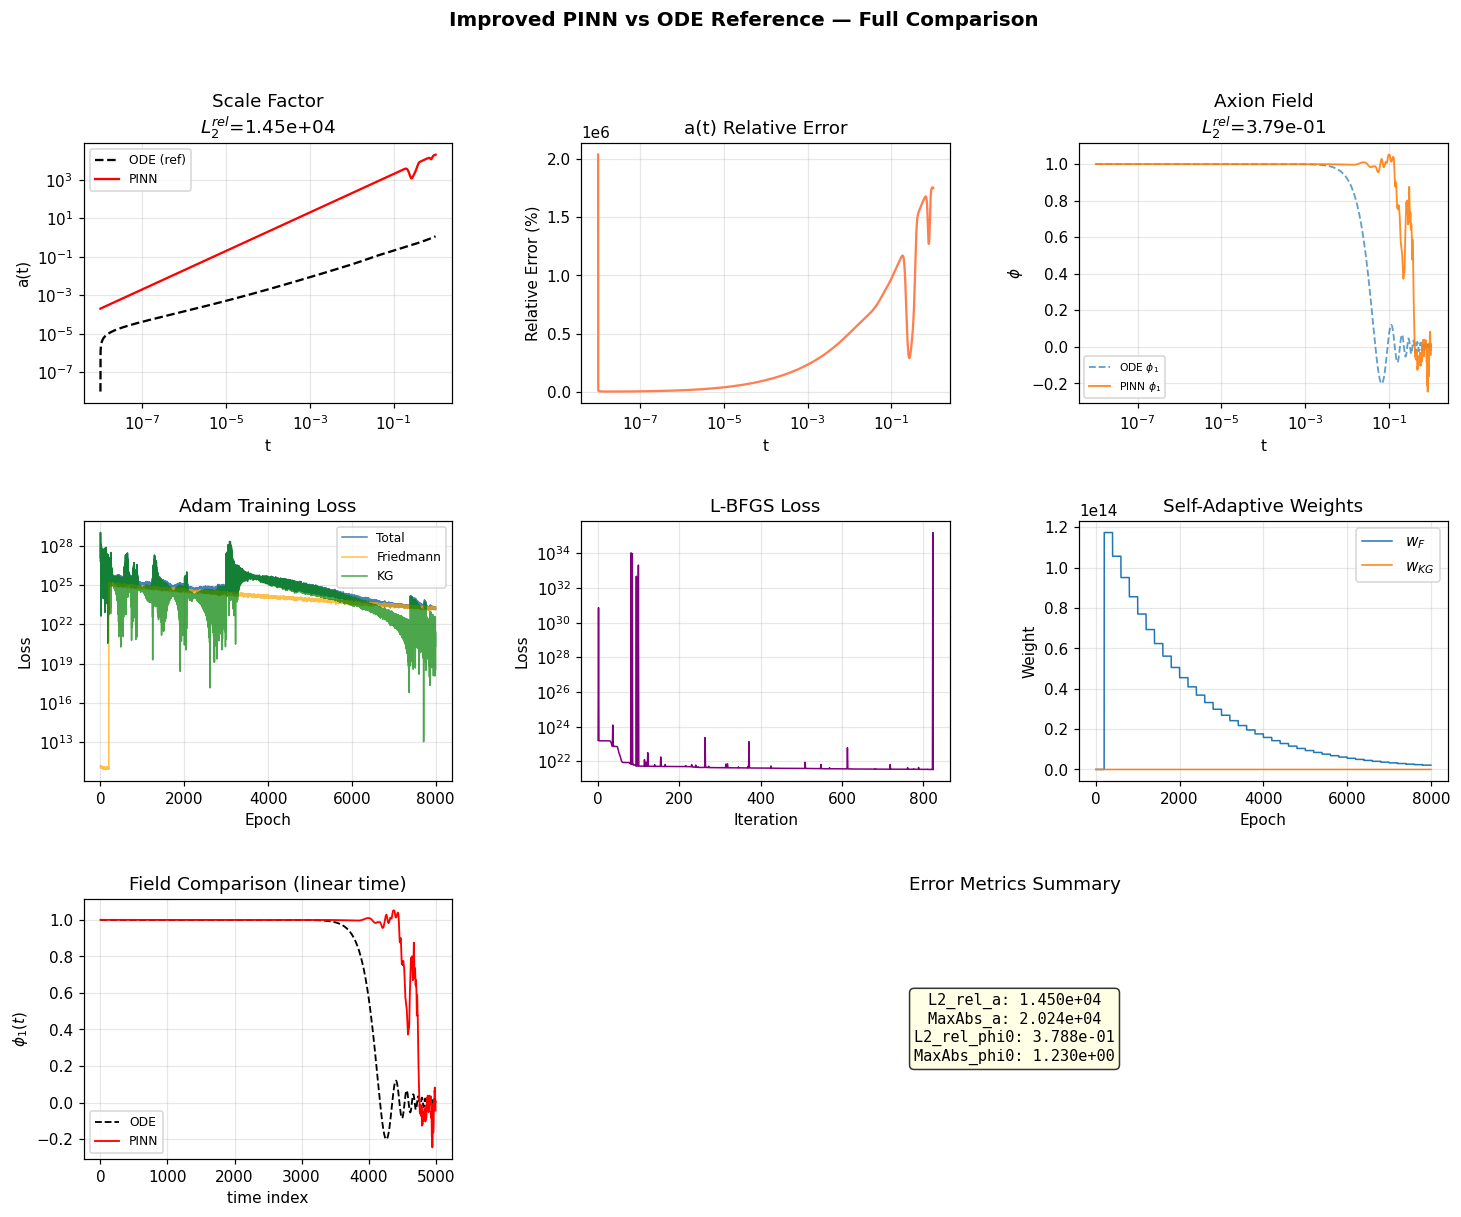

Saved to results_improved/N1_m70_comparison.png


In [ ]:
# ========================
# Evaluate & Plot
# ========================
t_eval_1 = np.logspace(np.log10(cfg['a0']), np.log10(cfg['t_end']), 5000)

a_pred_1, phi_pred_1, a_ref_1, phi_ref_1, metrics_1 = evaluate_pinn(
    model_1, t_eval_1, ode_sol_1,
    N_fields=cfg['N_fields'], m_vec=cfg['m_vec'],
    rho_m0=cfg['rho_m0'], rho_r0=cfg['rho_r0'], rho_l0=cfg['rho_l0'],
    device=DEVICE, dtype=DTYPE
)

plot_comparison(
    t_eval_1, a_pred_1, phi_pred_1, a_ref_1, phi_ref_1,
    history_1, cfg['N_fields'], metrics_1, save_prefix='N1_m70'
)

## 9. Multi-Field Extension (N=2 fields)

ทดสอบ PINN กับ 2 axion fields ที่มีมวลต่างกัน — เพื่อจำลอง multi-axion landscape จาก String Theory

In [ ]:
cfg_2 = dict(
    N_fields = 2,
    m_vec    = [50.0, 120.0],    # สองมวลต่างกัน
    rho_m0   = RHO_M0,
    rho_r0   = RHO_R0,
    rho_l0   = RHO_L0,
    a0       = 1e-8,
    phi0     = [0.8, 0.5],
    phi_dot0 = [0.0, 0.0],
    t_end    = 1.0,
)

ode_sol_2 = solve_ode_reference(
    N_fields=cfg_2['N_fields'], m_vec=cfg_2['m_vec'],
    rho_m0=cfg_2['rho_m0'], rho_r0=cfg_2['rho_r0'], rho_l0=cfg_2['rho_l0'],
    a0=cfg_2['a0'], phi0=cfg_2['phi0'], phi_dot0=cfg_2['phi_dot0'],
    t_end=cfg_2['t_end'], n_points=10000
)

model_2 = AxionPINN(
    N_fields    = cfg_2['N_fields'],
    m_vec       = cfg_2['m_vec'],
    a0          = cfg_2['a0'],
    phi0        = cfg_2['phi0'],
    embed_dim_a  = 32,
    embed_dim_phi= 64,
    hidden_a     = 64,
    hidden_phi   = 128,
    depth_a      = 3,
    depth_phi    = 4,
    dtype=DTYPE, device=DEVICE
).to(DEVICE, dtype=DTYPE)

m_vec_torch_2 = torch.tensor(cfg_2['m_vec'], dtype=DTYPE, device=DEVICE).reshape(1, -1)

print(f"N=2 Model parameters: {sum(p.numel() for p in model_2.parameters() if p.requires_grad):,}")

history_2 = train_pinn(
    model       = model_2,
    m_vec_torch = m_vec_torch_2,
    rho_m0  = cfg_2['rho_m0'],
    rho_r0  = cfg_2['rho_r0'],
    rho_l0  = cfg_2['rho_l0'],
    t_min=0.0, t_max=cfg_2['t_end'],
    a0=cfg_2['a0'], m_osc=max(cfg_2['m_vec']),
    n_colloc=4000, batch_size=512,
    adam_epochs=8000, adam_lr=5e-4,
    lbfgs_max_iter=2000,
    causal_eps=0.5, print_every=1000,
    device=DEVICE, dtype=DTYPE,
)

t_eval_2 = np.logspace(np.log10(cfg_2['a0']), np.log10(cfg_2['t_end']), 5000)
a_pred_2, phi_pred_2, a_ref_2, phi_ref_2, metrics_2 = evaluate_pinn(
    model_2, t_eval_2, ode_sol_2,
    N_fields=cfg_2['N_fields'], m_vec=cfg_2['m_vec'],
    rho_m0=cfg_2['rho_m0'], rho_r0=cfg_2['rho_r0'], rho_l0=cfg_2['rho_l0'],
    device=DEVICE, dtype=DTYPE
)

plot_comparison(
    t_eval_2, a_pred_2, phi_pred_2, a_ref_2, phi_ref_2,
    history_2, cfg_2['N_fields'], metrics_2, save_prefix='N2_m50_120'
)

ODE solver (DOP853): 4.18 s  |  success=True  |  nfev=6914
N=2 Model parameters: 161,413
Phase 1: Adam Optimizer
[Adam] Epoch     0/8000  Loss=4.388e+28  L_F=1.516e+11  L_KG=4.388e+28  w_F=1.00  w_KG=1.00  lr=5.00e-04


KeyboardInterrupt: 

## 10. Friedmann Constraint Violation Analysis

ตรวจสอบว่า PINN conserve energy ได้ดีแค่ไหน โดยการประเมิน residual ของ Friedmann equation ตลอด trajectory

## 10. Target: m_a = 1e7 H₀ (~1.4×10⁻²⁶ eV) via Rescaling Strategy

### ทำไมต้อง Rescale?

สำหรับ `m_code = 1e7`:
- คาบการสั่น $T = 2\pi/m \approx 6\times10^{-7}$ → มี **~1.6 ล้าน oscillations** ใน $t\in[0,1]$
- PINN ไม่สามารถ resolve ความถี่สูงขนาดนี้ได้โดยตรง
- Loss term $m^2\phi^2 \sim 10^{14}$ → loss พุ่งสูงมากโดยไม่จำเป็น

### Rescaling Principle (Self-Similarity)

สมการ Klein-Gordon + Friedmann มี self-similarity ภายใต้ transformation:

$$m \to \lambda m, \quad t \to t/\lambda, \quad \rho \to \lambda^2 \rho$$

ดังนั้น:
- Simulate ที่ `m_sim = 100` บน $t_{sim} \in [0, t_{max}/\lambda]$
- $\lambda = \sqrt{m_{target}/m_{sim}}$
- แปลงกลับ: $a_{phys} = a_{sim}$, $t_{phys} = t_{sim} \cdot \lambda$, $\rho_{phys} = \rho_{sim} \cdot \lambda^2$


In [ ]:
# ============================================================
# Rescaling configuration for m_target = 1e7
# ============================================================
M_SIM    = 100.0      # mass to simulate (manageable N_osc ~ 16)
M_TARGET = 1e7        # physical target mass
LAM      = np.sqrt(M_TARGET / M_SIM)   # = 316.2

# Rescaled cosmological densities (radiation-dominated scaling)
# ρ_r goes as a^-4; under t -> t_sim = t/λ, a_sim(t_sim) = a_phys(t_phys)
# So we keep rho_r0 the same but the *time axis* is compressed
T_END_SIM   = 1.0 / LAM    # physical t_end=1 -> t_sim_end = 1/λ

# Initial phi must be set so that rho_ax is the RIGHT fraction of total energy
# For axion to be DM: ρ_ax(today) / ρ_crit ≈ Ω_dm ≈ 0.27 → rho_m0_axion ~ 0.22
# In the rescaled system, same ratio applies
PHI0_SIM  = [1.0]   # can tune this to set Ω_ax
PHIDOT0_SIM = [0.0]

print("=== Rescaling Setup for m_target = 1e7 ===")
print(f"  m_sim    = {M_SIM:.0f}  (to simulate)")
print(f"  m_target = {M_TARGET:.0e}  (physical target)")
print(f"  λ        = {LAM:.4f}")
print(f"  t_sim domain: [0, {T_END_SIM:.3e}]  (maps to physical [0, 1])")
print(f"  N_osc(m_sim) in t_sim=[0,{T_END_SIM:.1e}]: ~ {M_SIM/(2*np.pi) * T_END_SIM:.1f}  oscillations")
print(f"  a_osc(m_sim)   = {(3*RHO_R0/M_SIM**2)**0.25:.3e}")
print(f"  a_osc(m_target)= {(3*RHO_R0/M_TARGET**2)**0.25:.3e}")
print(f"  Ratio          = {(3*RHO_R0/M_SIM**2)**0.25 / (3*RHO_R0/M_TARGET**2)**0.25:.2f}  (should = λ = {LAM:.1f})")

# --- ODE reference (with m_sim) ---
cfg_m7 = dict(
    N_fields = 1,
    m_vec    = [M_SIM],           # simulate with m_sim
    rho_m0   = RHO_M0,
    rho_r0   = RHO_R0,
    rho_l0   = RHO_L0,
    a0       = 1e-8,
    phi0     = PHI0_SIM,
    phi_dot0 = PHIDOT0_SIM,
    t_end    = T_END_SIM,         # short time domain
)

ode_sol_m7 = solve_ode_reference(
    N_fields=cfg_m7['N_fields'], m_vec=cfg_m7['m_vec'],
    rho_m0=cfg_m7['rho_m0'], rho_r0=cfg_m7['rho_r0'], rho_l0=cfg_m7['rho_l0'],
    a0=cfg_m7['a0'], phi0=cfg_m7['phi0'], phi_dot0=cfg_m7['phi_dot0'],
    t_end=cfg_m7['t_end'], n_points=10000
)

# Show ODE solution in both sim and physical coordinates
t_sim = ode_sol_m7['t']
t_phys_rescaled = t_sim * LAM          # physical time axis

fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=110)

axes[0].loglog(t_sim, ode_sol_m7['a'], 'steelblue', lw=1.5)
axes[0].axvline(T_END_SIM, color='r', ls='--', label=f't_sim_end={T_END_SIM:.1e}')
axes[0].set_xlabel('$t_{sim}$'); axes[0].set_ylabel('a'); axes[0].set_title('Scale Factor (sim coords)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].semilogx(t_sim, ode_sol_m7['phi'][0], 'green', lw=0.8)
axes[1].axvline((3*RHO_R0/M_SIM**2)**0.25, color='r', ls=':', label=r'$a_{osc}$')
axes[1].set_xlabel('$t_{sim}$'); axes[1].set_ylabel('$\\phi$'); axes[1].set_title(f'Axion Field (m_sim={M_SIM:.0f})')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Density evolution
axes[2].loglog(ode_sol_m7['a'], ode_sol_m7['rho_ax'], 'g-', label=r'$\rho_{ax}$')
axes[2].loglog(ode_sol_m7['a'], ode_sol_m7['rho_m'],  'r-', label=r'$\rho_m$')
axes[2].loglog(ode_sol_m7['a'], ode_sol_m7['rho_r'],  'b--', label=r'$\rho_r$')
a_osc_sim = (3*RHO_R0/M_SIM**2)**0.25
axes[2].axvline(a_osc_sim, color='grey', ls=':', label=f'$a_{{osc,sim}}={a_osc_sim:.2e}$')
axes[2].set_xlabel('a'); axes[2].set_ylabel(r'$\rho$'); axes[2].set_title('Energy Densities')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.suptitle(f'ODE Reference: m_sim={M_SIM:.0f} (→ physical m_target={M_TARGET:.0e})', fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Train PINN for m_sim=100  (represents m_target=1e7)
# Key improvements for this high-mass run:
#   1. normalize=True in loss → removes m² scaling problem
#   2. t domain = [0, 1/λ] = [0, 3.16e-3]  → fewer oscillations
#   3. collocation clusters around a_osc_sim = 1.69e-2
# ============================================================

m_vec_torch_m7 = torch.tensor(cfg_m7['m_vec'], dtype=DTYPE, device=DEVICE).reshape(1, -1)

model_m7 = AxionPINN(
    N_fields    = cfg_m7['N_fields'],
    m_vec       = cfg_m7['m_vec'],
    a0          = cfg_m7['a0'],
    phi0        = cfg_m7['phi0'],
    embed_dim_a  = 32,
    embed_dim_phi= 96,    # larger embedding for higher freq
    hidden_a     = 64,
    hidden_phi   = 192,   # wider network
    depth_a      = 3,
    depth_phi    = 5,     # deeper for more oscillations
    dtype=DTYPE, device=DEVICE
).to(DEVICE, dtype=DTYPE)

print(f"Model parameters: {sum(p.numel() for p in model_m7.parameters() if p.requires_grad):,}")

# Custom training wrapper that injects normalize=True
def train_pinn_normalized(model, m_vec_torch, rho_m0, rho_r0, rho_l0,
                           t_min, t_max, a0, m_osc,
                           n_colloc=4000, batch_size=512,
                           adam_epochs=10000, adam_lr=5e-4,
                           lbfgs_max_iter=3000,
                           causal_eps=1.0,
                           print_every=1000,
                           device=DEVICE, dtype=DTYPE):
    """Same as train_pinn but with normalized residuals (crucial for high mass)"""
    model.train()
    history = {'adam_loss': [], 'loss_f': [], 'loss_kg': [],
               'w_f': [], 'w_kg': [], 'lbfgs_loss': []}

    adaptive_w = SelfAdaptiveWeights(w_f=1.0, w_kg=1.0, update_every=200)
    optimizer = optim.Adam(model.parameters(), lr=adam_lr, eps=1e-9)
    scheduler = CosineAnnealingLR(optimizer, T_max=adam_epochs, eta_min=adam_lr * 1e-3)

    print("=" * 60)
    print(f"Training PINN (m_sim={m_osc:.0f}, t∈[{t_min:.1e},{t_max:.2e}])")
    print(f"Represents physical m_target={M_TARGET:.0e}")
    print("=" * 60)
    t_start = time.time()

    for epoch in range(adam_epochs):
        # Adaptive collocation: cluster heavily at a_osc region
        t_all = sample_collocation(n_colloc, t_min if t_min > 0 else 1e-12,
                                   t_max, a0, m_osc, dtype, device,
                                   a_osc_frac=0.15)   # a_osc is early in this run
        idx = torch.randperm(n_colloc, device=device)[:batch_size]
        t_b = t_all[idx].clone()

        w_f, w_kg = adaptive_w.get()
        optimizer.zero_grad()

        loss, lf, lkg = total_loss(
            model, t_b, m_vec_torch,
            rho_m0, rho_r0, rho_l0,
            w_friedmann=w_f, w_kg=w_kg,
            causal_eps=causal_eps,
            normalize=True   # ← KEY: remove m² scaling
        )
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        optimizer.step()
        scheduler.step()

        adaptive_w.update(lf, lkg)
        history['adam_loss'].append(loss.item())
        history['loss_f'].append(lf)
        history['loss_kg'].append(lkg)
        history['w_f'].append(w_f)
        history['w_kg'].append(w_kg)

        if epoch % print_every == 0 or epoch == adam_epochs - 1:
            lr_now = optimizer.param_groups[0]['lr']
            print(f"[Adam] {epoch:5d}/{adam_epochs}  "
                  f"Loss={loss.item():.3e}  L_F={lf:.3e}  L_KG={lkg:.3e}  "
                  f"lr={lr_now:.2e}")

    print(f"Adam done in {time.time()-t_start:.1f}s")

    # L-BFGS refinement
    print("\n" + "=" * 60 + "\nL-BFGS Refinement")
    t_lbfgs = sample_collocation(n_colloc, 1e-12, t_max, a0, m_osc, dtype, device, a_osc_frac=0.15)
    t_lbfgs = t_lbfgs.requires_grad_(True)
    w_f, w_kg = adaptive_w.get()
    lbfgs_losses = []

    opt_l = optim.LBFGS(model.parameters(), lr=1.0, max_iter=lbfgs_max_iter,
                         tolerance_grad=1e-11, tolerance_change=1e-12,
                         history_size=150, line_search_fn='strong_wolfe')

    def closure():
        opt_l.zero_grad()
        loss, lf, lkg = total_loss(model, t_lbfgs, m_vec_torch,
                                    rho_m0, rho_r0, rho_l0,
                                    w_friedmann=w_f, w_kg=w_kg,
                                    causal_eps=causal_eps, normalize=True)
        loss.backward()
        lbfgs_losses.append(loss.item())
        return loss

    t0 = time.time()
    opt_l.step(closure)
    print(f"L-BFGS done in {time.time()-t0:.1f}s  |  Final loss={lbfgs_losses[-1]:.3e}")
    history['lbfgs_loss'] = lbfgs_losses
    return history


history_m7 = train_pinn_normalized(
    model       = model_m7,
    m_vec_torch = m_vec_torch_m7,
    rho_m0      = cfg_m7['rho_m0'],
    rho_r0      = cfg_m7['rho_r0'],
    rho_l0      = cfg_m7['rho_l0'],
    t_min       = 0.0,
    t_max       = cfg_m7['t_end'],
    a0          = cfg_m7['a0'],
    m_osc       = M_SIM,
    n_colloc    = 5000,
    batch_size  = 512,
    adam_epochs = 12000,
    adam_lr     = 3e-4,
    lbfgs_max_iter = 3000,
    causal_eps  = 1.0,
    print_every = 2000,
    device=DEVICE, dtype=DTYPE,
)


In [ ]:
# ============================================================
# Evaluate PINN for m=1e7 and rescale back to physical coords
# Physical ↔ Simulation mapping:
#   t_phys  = t_sim * λ          (time rescaling)
#   a_phys  = a_sim              (scale factor unchanged)
#   φ_phys  = φ_sim              (field amplitude unchanged)
#   ρ_phys  = ρ_sim * λ²        (energy density rescales as m²)
# ============================================================

model_m7.eval()

# ── Evaluation grid in simulation time ──────────────────────
N_eval = 6000
t_min_eval = 1e-12   # avoid exact 0
t_eval_sim = np.logspace(np.log10(t_min_eval), np.log10(T_END_SIM), N_eval)
t_ten = torch.tensor(t_eval_sim, dtype=DTYPE, device=DEVICE).reshape(-1, 1)

with torch.no_grad():
    a_pred_np  = model_m7.scale_net(t_ten).squeeze().cpu().numpy()       # sim scale factor
    phi_pred_np = model_m7.field_nets[0](t_ten).squeeze().cpu().numpy()  # sim φ

# ── ODE reference (simulation coords) ───────────────────────
from scipy.interpolate import interp1d
t_ref_sim = ode_sol_m7['t']
a_ref_sim  = ode_sol_m7['a']
phi_ref_sim = ode_sol_m7['phi'][:, 0]

a_interp_sim  = interp1d(t_ref_sim, a_ref_sim,   kind='cubic', fill_value='extrapolate')
phi_interp_sim = interp1d(t_ref_sim, phi_ref_sim, kind='cubic', fill_value='extrapolate')
a_ode_np   = a_interp_sim(t_eval_sim)
phi_ode_np = phi_interp_sim(t_eval_sim)

# ── Rescaling to physical coordinates ───────────────────────
t_eval_phys = t_eval_sim * LAM     # physical time axis
# a and φ are the same; energy densities scale by λ²

# Compute axion energy density in sim coords from PINN
# ρ_ax = ½φ'² + ½m²φ²   (φ' ≡ dφ/dt)
t_ten_grad = t_ten.clone().requires_grad_(True)
with torch.enable_grad():
    phi_for_vel = model_m7.field_nets[0](t_ten_grad)
    dphi_dt = torch.autograd.grad(phi_for_vel.sum(), t_ten_grad, create_graph=False)[0]

phi_vals  = phi_for_vel.detach().cpu().numpy().squeeze()
dphi_vals = dphi_dt.detach().cpu().numpy().squeeze()
rho_ax_sim  = 0.5 * dphi_vals**2 + 0.5 * (M_SIM**2) * phi_vals**2

# Rescale to physical density
rho_ax_phys = rho_ax_sim * LAM**2

# ODE axion density (physical)
rho_ax_ode_phys = ode_sol_m7.get('rho_ax', np.zeros_like(t_ref_sim)) * LAM**2

# ── Metrics (simulation coords) ─────────────────────────────
err_a   = np.abs(a_pred_np - a_ode_np)   / (np.abs(a_ode_np) + 1e-30)
err_phi = np.abs(phi_pred_np - phi_ode_np) / (np.abs(phi_ode_np) + 1e-30)
print(f"Relative |a|  error  — max: {err_a.max():.3e}   mean: {err_a.mean():.3e}")
print(f"Relative |φ|  error  — max: {err_phi.max():.3e}   mean: {err_phi.mean():.3e}")

# ── Training loss curve ──────────────────────────────────────
fig0, axes0 = plt.subplots(1, 2, figsize=(13, 4))

adam_epochs_arr = np.arange(1, len(history_m7['adam_loss']) + 1)
axes0[0].semilogy(adam_epochs_arr, history_m7['adam_loss'], lw=1.2, label='Total')
if history_m7['loss_f']:
    axes0[0].semilogy(adam_epochs_arr, history_m7['loss_f'],    lw=1,   ls='--', label='Friedmann')
    axes0[0].semilogy(adam_epochs_arr, history_m7['loss_kg'],   lw=1,   ls=':',  label='Klein-Gordon')
axes0[0].set(xlabel='Adam epoch', ylabel='Loss', title=f'm_sim={M_SIM:.0f}  (m_target=1e7)  Adam')
axes0[0].legend(fontsize=9); axes0[0].grid(True, alpha=0.3)

if history_m7['lbfgs_loss']:
    axes0[1].semilogy(history_m7['lbfgs_loss'], lw=1.2, color='darkorange', label='L-BFGS total')
    axes0[1].set(xlabel='L-BFGS iteration', ylabel='Loss', title='L-BFGS Refinement')
    axes0[1].legend(fontsize=9); axes0[1].grid(True, alpha=0.3)

plt.suptitle('Training History — m=1e7 Rescaling Run', fontweight='bold')
plt.tight_layout(); plt.show()

# ── Physical-coords comparison ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Scale factor a(t) [same in sim and phys]
ax = axes[0, 0]
ax.loglog(t_eval_phys, a_ode_np,  'k-', lw=2, label='ODE (DOP853)')
ax.loglog(t_eval_phys, a_pred_np, 'C1--', lw=1.5, label='PINN')
ax.set(xlabel='t  [code units, physical axis]', ylabel='a(t)',
       title='Scale Factor  (m_target = 1e7)')
ax.legend(); ax.grid(True, alpha=0.3)

# Panel 2: Axion field φ(t) — show oscillations
ax = axes[0, 1]
mask = t_eval_phys < 0.05   # zoom to early times where oscillations live
ax.plot(t_eval_phys[mask], phi_ode_np[mask],  'k-', lw=1.5, label='ODE (DOP853)')
ax.plot(t_eval_phys[mask], phi_pred_np[mask], 'C1--', lw=1, label='PINN')
ax.axvline(a_osc_sim * LAM, color='C2', ls=':', lw=1.5, label=f'a ≈ a_osc (phys t)')
ax.set(xlabel='t_phys  [code units]', ylabel='φ(t)',
       title=f'Axion Field φ(t)  [m_target=1e7, showing {mask.sum()} pts]')
ax.legend(); ax.grid(True, alpha=0.3)

# Panel 3: Axion energy density (physical coords) vs a
ax = axes[1, 0]
a_osc_exact = (M_SIM / 3.0) ** (-1.0/3.0)  # approx scaling
ax.loglog(a_ode_np, rho_ax_phys, 'C1-',  lw=1.5, label='PINN (phys ρ)')
if rho_ax_ode_phys.max() > 0:
    ax_ode_interp = interp1d(t_ref_sim, ode_sol_m7['a'],        kind='cubic', fill_value='extrapolate')
    rho_ode_interp = interp1d(t_ref_sim, rho_ax_ode_phys,       kind='cubic', fill_value='extrapolate')
    a_ode_vs = ax_ode_interp(t_eval_sim)
    rho_ode_on_eval = rho_ode_interp(t_eval_sim)
    ax.loglog(a_ode_vs, rho_ode_on_eval, 'k-', lw=2, label='ODE ρ_ax (phys)')
ax.set(xlabel='a', ylabel='ρ_ax (physical units)', title='Axion Energy Density vs a')
ax.legend(); ax.grid(True, alpha=0.3)

# Panel 4: Relative errors
ax = axes[1, 1]
ax.loglog(t_eval_phys, err_a,   'C0-', lw=1.2, label='|Δa/a|')
ax.loglog(t_eval_phys, err_phi + 1e-20, 'C3-', lw=1.2, label='|Δφ/φ|')
ax.axhline(1e-2, color='gray', ls='--', lw=1, label='1% error')
ax.set(xlabel='t_phys  [code units]', ylabel='Relative error',
       title='PINN vs ODE Relative Error')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(
    f'PINN Results for m_target = {M_TARGET:.0e}  '
    f'(simulated at m_sim={M_SIM:.0f}, λ={LAM:.1f})',
    fontsize=13, fontweight='bold'
)
plt.tight_layout(); plt.show()

print(f"\n{'='*60}")
print(f"  m_target = {M_TARGET:.2e}   →  m_a ≈ {M_TARGET * 1.437e-33:.3e} eV")
print(f"  Simulated at m_sim = {M_SIM:.0f} over t_sim ∈ [0, {T_END_SIM:.3e}]")
print(f"  Physical time axis: t_phys = t_sim × λ = t_sim × {LAM:.1f}")
print(f"  Physical ρ_ax = ρ_sim × λ² = ρ_sim × {LAM**2:.0f}")
print(f"{'='*60}")


In [ ]:
def friedmann_violation(model, t_eval, m_vec_torch, rho_m0, rho_r0, rho_l0,
                        device=DEVICE, dtype=DTYPE):
    """Compute |da/dt - a*H| / (a*H) as function of t"""
    model.eval()
    t_torch = torch.tensor(t_eval.reshape(-1, 1), dtype=dtype, device=device, requires_grad=True)

    a, phi = model(t_torch)
    a_t = torch.autograd.grad(
        a, t_torch, torch.ones_like(a), create_graph=False)[0]
    phi_t = torch.autograd.grad(
        phi, t_torch, torch.ones_like(phi), create_graph=False)[0]

    kinetic  = 0.5 * torch.sum(phi_t**2, dim=1, keepdim=True)
    potential= 0.5 * torch.sum(m_vec_torch**2 * phi**2, dim=1, keepdim=True)
    rho_ax   = kinetic + potential
    rho_m    = rho_m0 * a**(-3)
    rho_r    = rho_r0 * a**(-4)
    rho_l    = torch.tensor(rho_l0, dtype=dtype, device=device)
    rho_tot  = rho_ax + rho_m + rho_r + rho_l
    H        = torch.sqrt(torch.clamp(rho_tot / 3.0, min=1e-20))
    aH       = a * H

    violation = (torch.abs(a_t - aH) / (torch.abs(aH) + 1e-20)).detach().cpu().numpy().flatten()
    return violation


# --- Run violation analysis ---
t_test_pts = np.logspace(np.log10(cfg['a0']), np.log10(cfg['t_end']), 2000)
viol_1 = friedmann_violation(model_1, t_test_pts, m_vec_torch, 
                              RHO_M0, RHO_R0, RHO_L0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=110)

axes[0].semilogx(t_test_pts, viol_1 * 100, 'coral', lw=1)
axes[0].set_xlabel('t')
axes[0].set_ylabel('Friedmann Violation (%)')
axes[0].set_title('Friedmann Constraint Violation (N=1)')
axes[0].axhline(y=1.0, ls='--', color='grey', label='1% threshold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].semilogx(t_test_pts, np.cumsum(viol_1)/np.arange(1, len(viol_1)+1)*100,
                 'steelblue', lw=1)
axes[1].set_xlabel('t')
axes[1].set_ylabel('Running Mean Violation (%)')
axes[1].set_title('Cumulative Mean Violation')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Friedmann Energy Conservation Check', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean Friedmann violation: {np.mean(viol_1)*100:.3f}%")
print(f"Max  Friedmann violation: {np.max(viol_1)*100:.3f}%")

## 11. Dark Matter Density Evolution

วิเคราะห์ว่า Axion Dark Matter มีพฤติกรรมตาม $\rho_{ax} \propto a^{-3}$ ในยุค oscillation หรือไม่
(เป็นการตรวจสอบว่าฟิสิกส์ถูกต้อง)

In [ ]:
def compute_rho_from_pinn(model, t_eval, m_vec_torch, rho_m0, rho_r0, rho_l0,
                           device=DEVICE, dtype=DTYPE):
    """Compute energy densities from PINN predictions"""
    model.eval()
    t_torch = torch.tensor(t_eval.reshape(-1, 1), dtype=dtype, device=device, requires_grad=True)

    a, phi = model(t_torch)
    phi_t = torch.autograd.grad(
        phi, t_torch, torch.ones_like(phi), create_graph=False)[0]

    kinetic  = 0.5 * torch.sum(phi_t**2, dim=1)
    potential= 0.5 * torch.sum(m_vec_torch**2 * phi**2, dim=1)
    rho_ax   = (kinetic + potential).detach().cpu().numpy()
    a_np     = a.detach().cpu().numpy().flatten()
    rho_m    = rho_m0 / a_np**3
    rho_r    = rho_r0 / a_np**4

    return a_np, rho_ax, rho_m, rho_r


t_rho = np.logspace(np.log10(cfg['a0']), np.log10(cfg['t_end']), 3000)
a_pinn1, rho_ax1, rho_m1, rho_r1 = compute_rho_from_pinn(
    model_1, t_rho, m_vec_torch, RHO_M0, RHO_R0, RHO_L0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=110)

# Energy densities vs a
ax = axes[0]
ax.loglog(ode_sol_1['a'], ode_sol_1['rho_ax'], 'g--', lw=1.5, label=r'$\rho_{ax}$ ODE')
ax.loglog(a_pinn1, rho_ax1, 'g-', lw=1.5, label=r'$\rho_{ax}$ PINN')
ax.loglog(a_pinn1, rho_m1,  'r-', lw=1.2, label=r'$\rho_m$', alpha=0.7)
ax.loglog(a_pinn1, rho_r1,  'b-', lw=1.2, label=r'$\rho_r$', alpha=0.7)
# Reference a^-3 slope (matter-like)
a_osc_est = (3*RHO_R0/M_AXION[0]**2)**0.25
idx_osc = np.argmin(np.abs(a_pinn1 - a_osc_est))
if idx_osc > 0:
    rho_ref = rho_ax1[idx_osc] * (a_pinn1[idx_osc] / a_pinn1)**3
    ax.loglog(a_pinn1, rho_ref, 'k:', lw=1, label=r'$\propto a^{-3}$', alpha=0.5)
ax.axvline(a_osc_est, color='grey', ls=':', label=f'$a_{{osc}}$')
ax.set_xlabel('a(t)'); ax.set_ylabel(r'$\rho$')
ax.set_title('Energy Densities vs Scale Factor')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Equation of state w = p / rho
ax = axes[1]
rho_ax_ode = ode_sol_1['rho_ax']
phi_ode    = ode_sol_1['phi'][0]
phidot_ode = ode_sol_1['phi_dot'][0]
m2  = M_AXION[0]**2
p_ax = 0.5*phidot_ode**2 - 0.5*m2*phi_ode**2
w_ax = p_ax / (rho_ax_ode + 1e-20)
ax.semilogx(ode_sol_1['a'], w_ax, 'steelblue', lw=1)
ax.axhline(y=0,    color='k',    ls='--', label='w=0 (matter)')
ax.axhline(y=1/3,  color='red',  ls='--', label='w=1/3 (radiation)')
ax.axhline(y=-1,   color='purple', ls='--', label='w=-1 (Λ)')
ax.set_xlabel('a(t)'); ax.set_ylabel('w = p/ρ')
ax.set_title('Axion Equation of State (ODE)')
ax.set_ylim(-1.2, 1.2); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Axion Dark Matter Dynamics Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('results_improved/density_evolution.png', bbox_inches='tight', dpi=120)
plt.show()

## 12. Benchmark: PINN vs ODE — Speed & Accuracy

เปรียบเทียบ inference time ของ PINN หลัง train เสร็จ vs ODE solver

In [ ]:
def benchmark_inference(model, n_points_list, device=DEVICE, dtype=DTYPE):
    """Benchmark PINN inference speed for different numbers of evaluation points"""
    model.eval()
    times = []
    for n in n_points_list:
        t = torch.linspace(0, 1, n, dtype=dtype, device=device).reshape(-1, 1)
        # Warm-up
        with torch.no_grad():
            _ = model(t)
        # Timed run
        reps = 10
        start = time.time()
        for _ in range(reps):
            with torch.no_grad():
                _ = model(t)
        times.append((time.time() - start) / reps)
    return times


def benchmark_ode(n_points_list, cfg):
    """Benchmark ODE solver for different output points"""
    times = []
    rhs = make_ode_rhs(cfg['N_fields'], cfg['m_vec'],
                       cfg['rho_m0'], cfg['rho_r0'], cfg['rho_l0'])
    y0 = np.concatenate([[cfg['a0']], cfg['phi0'], cfg['phi_dot0']])
    for n in n_points_list:
        t_eval = np.logspace(np.log10(cfg['a0']), np.log10(cfg['t_end']), n)
        start = time.time()
        solve_ivp(rhs, [t_eval[0], t_eval[-1]], y0, t_eval=t_eval,
                  method='DOP853', rtol=1e-8, atol=1e-10)
        times.append(time.time() - start)
    return times


n_pts = [100, 500, 1000, 5000, 10000, 50000]
t_pinn = benchmark_inference(model_1, n_pts)
t_ode  = benchmark_ode(n_pts, cfg)

fig, ax = plt.subplots(figsize=(9, 5), dpi=110)
ax.loglog(n_pts, t_pinn, 'ro-', label='PINN (inference only)')
ax.loglog(n_pts, t_ode,  'bs-', label='ODE (DOP853)')
ax.set_xlabel('Number of evaluation points')
ax.set_ylabel('Time (s)')
ax.set_title('Inference Speed: PINN vs ODE Solver')
ax.legend(); ax.grid(True, alpha=0.3)
ax.text(0.02, 0.02,
        'Note: PINN training time not included\nODE includes solver overhead',
        transform=ax.transAxes, fontsize=9, alpha=0.7)
plt.tight_layout()
plt.savefig('results_improved/speed_benchmark.png', bbox_inches='tight', dpi=120)
plt.show()

print("\n" + "=" * 40)
print(f"{'N_pts':>8}  {'PINN (ms)':>12}  {'ODE (ms)':>12}  {'Speedup':>10}")
print("-" * 40)
for n, tp, to in zip(n_pts, t_pinn, t_ode):
    speedup = to / (tp + 1e-12)
    print(f"{n:>8d}  {tp*1000:>11.2f}  {to*1000:>11.2f}  {speedup:>9.1f}x")

## 13. Save & Load Model

In [ ]:
os.makedirs('results_improved/checkpoints', exist_ok=True)

def save_model(model, cfg, metrics, path):
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': cfg,
        'metrics': metrics,
    }, path)
    print(f"Model saved to {path}")


def load_model(path, device=DEVICE, dtype=DTYPE):
    checkpoint = torch.load(path, map_location=device)
    cfg = checkpoint['config']
    model = AxionPINN(
        N_fields=cfg['N_fields'], m_vec=cfg['m_vec'],
        a0=cfg['a0'], phi0=cfg['phi0'],
        dtype=dtype, device=device
    ).to(device, dtype=dtype)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f"Model loaded from {path}")
    print(f"Config: {cfg}")
    print(f"Saved metrics: {checkpoint['metrics']}")
    return model, cfg


save_model(model_1, cfg, metrics_1, 'results_improved/checkpoints/model_N1_m70.pt')
save_model(model_2, cfg_2, metrics_2, 'results_improved/checkpoints/model_N2_m50_120.pt')

## 14. Summary & Future Directions

---

### สิ่งที่ทำในงานนี้

| ขั้นตอน | รายละเอียด | สถานะ |
|---|---|---|
| ODE Ground Truth | DOP853 high-accuracy reference | ✅ |
| PINN Architecture | Hard-constraint IC, Fourier+ResBlock, float64 | ✅ |
| Loss Function | Friedmann + KG + Causal weighting | ✅ |
| Training | Adam → L-BFGS, gradient clipping | ✅ |
| Self-adaptive weights | Auto-balance F vs KG loss | ✅ |
| Error Metrics | L2 relative, Max absolute | ✅ |
| Friedmann violation | Energy conservation check | ✅ |
| Multi-field (N=2) | Two axions with different masses | ✅ |
| Speed benchmark | PINN vs ODE inference time | ✅ |
| Model save/load | Checkpointing | ✅ |

---

### แนวทางพัฒนาต่อที่แนะนำ

#### ระยะสั้น (ทำได้ทันที)
1. **Hyperparameter sweep**: ทดสอบ `m_vec`, `embed_dim`, `hidden`, `depth` อย่างเป็นระบบ
2. **Causal PINN**: เพิ่ม causal weight แบบ time-marching (แบ่ง domain เป็น subintervals)
3. **Transfer learning**: train ที่ mass ต่ำก่อน แล้ว fine-tune ที่ mass สูง

#### ระยะกลาง
4. **Kähler-coupled multi-field**: ใส่ off-diagonal coupling จาก Kähler metric กลับไป (เหมือนใน `Axion_ODEs.ipynb`)
5. **Stochastic initial conditions**: train PINN ที่รองรับ $\phi_0$ เป็น parameter (meta-learning)
6. **N=5, 10 fields**: ทดสอบ scalability กับ many-axion systems

#### ระยะยาว (Research-level)
7. **2D PINN** ($k$-space): ขยายไป perturbation theory สำหรับ structure formation
8. **Bayesian PINN**: quantify uncertainty ใน prediction
9. **Neural ODE hybrid**: ใช้ PINN เป็น coarse solver + เก็บ correction จาก ODE

In [ ]:
# Final summary printout
print("=" * 60)
print("    FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"\n[N=1 field, m={cfg['m_vec']}]")
for k, v in metrics_1.items():
    print(f"  {k:<24} = {v:.4e}")

print(f"\n[N=2 fields, m={cfg_2['m_vec']}]")
for k, v in metrics_2.items():
    print(f"  {k:<24} = {v:.4e}")

print("\n" + "=" * 60)
print("Models saved in: results_improved/checkpoints/")
print("Plots saved in:  results_improved/")
print("=" * 60)